In [1]:
# If not already installed
# pip install xgboost scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier


In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=3,
    n_redundant=1,
    n_repeated=0,
    random_state=42
)

feature_names = ["CreditScore", "Age", "Income", "LoanAmount", "Gender", "CityScore"]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="LoanApproved")


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [4]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [5]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)


0.9466666666666667

In [6]:
importances = model.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "Feature": importances.keys(),
    "Importance": importances.values()
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
1,Age,25.298164
5,CityScore,5.345277
3,LoanAmount,3.029081
0,CreditScore,3.028069
2,Income,1.124403
4,Gender,0.969892


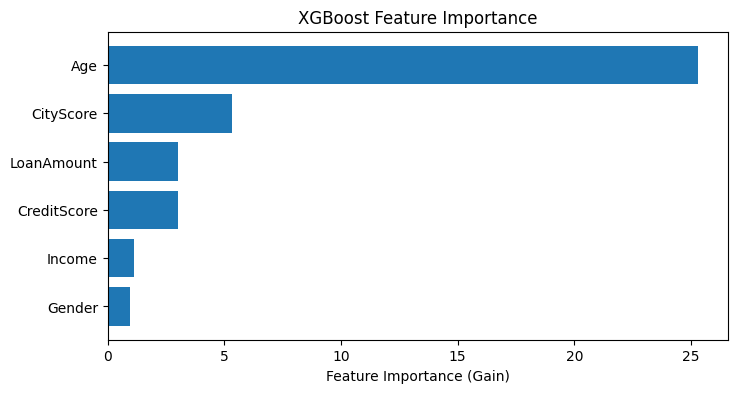

In [7]:
plt.figure(figsize=(8, 4))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)
plt.xlabel("Feature Importance (Gain)")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()
